In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1501.3490007755165
RUN  2 , total integrated cost =  698.5504480763045
RUN  3 , total integrated cost =  463.94991457517654
RUN  4 , total integrated cost =  327.3038219470977
RUN  5 , total integrated cost =  247.1369560477097
RUN  6 , total integrated cost =  195.03030637097507
RUN  7 , total integrated cost =  156.9276183414355
RUN  8 , total integrated cost =  128.4202582510654
RUN  9 , total integrated cost =  107.1821148020227
RUN  10 , total integrated cost =  89.10047297145616
RUN  11 , total integrated cost =  75.3982503998006
RUN  12 , total integrated cost =  63.490770026827406
RUN  13 , total integrated cost =  55.393846512076806
RUN  14 , total integrated cost =  50.00968969913001
RUN  15 , total integrated cost =  45.59106379553283
RUN  16 ,

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  362 , total integrated cost =  5379.979985628796
Improved over  362  iterations in  26.581255365163088  seconds by  8.769570269262488  percent.
Problem in initial value trasfer:  Vmean_exc -56.626856870105435 -56.62686001380965
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  713.5281248951585
RUN  2 , total integrated cost =  513.9335116362579
RUN  3 , total integrated cost =  357.8881535448636
RUN  4 , total integrated cost =  264.59972201795625
RUN  5 , total integrated cost =  186.29047641976513
RUN  6 , total integrated cost =  138.37401544462546
RUN  7 , total integrated cost =  102.41033275125447
RUN  8 , total integrated cost =  79.45563375545191
RUN  9 , total integrated cost =  62.53040171482778
RUN  10 , total integrated cost =  51.048853853015174
RUN

ERROR:root:Problem in initial value trasfer


RUN  2000 , total integrated cost =  0.7201977667402226
RUN  2000 , total integrated cost =  0.7201977667402226
Improved over  2000  iterations in  153.7033448945731  seconds by  99.99589657739766  percent.
Problem in initial value trasfer:  Vmean_exc -56.69066581240517 -56.69066579201892
weight =  243699.0037119362
set cost params:  1.0 243699.0037119362 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17545.102684140136
Gradient descend method:  None
RUN  1 , total integrated cost =  17010.4006129085
RUN  2 , total integrated cost =  16997.267677343916
RUN  3 , total integrated cost =  16984.680216308345
RUN  4 , total integrated cost =  16983.67359441263
RUN  5 , total integrated cost =  16981.612634457644
RUN  6 , total integrated cost =  16980.69077270908
RUN  7 , total integrated cost =  16971.78681308958
RUN  8 , total integrated cost =  16963.98399419797
RUN  9 , total integrated cost =  16960.962884663826
RUN  10 , total integrated cost =  16956.9603

...

RUN  3 , total integrated cost =  19611.73875380763
Control only changes marginally.
RUN  3 , total integrated cost =  19611.73875380763
Improved over  3  iterations in  0.30774541944265366  seconds by  5.875648412256851e-09  percent.
Problem in initial value trasfer:  Vmean_exc -74.59649283473463 -74.59649788430919
weight =  10.000000000587566
set cost params:  1.0 10.000000000587566 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19611.73875380763
Gradient descend method:  None
RUN  1 , total integrated cost =  19611.73875380763
Control only changes marginally.
RUN  1 , total integrated cost =  19611.73875380763
Improved over  1  iterations in  0.15743154846131802  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -74.59649283473463 -74.59649788430919
-------  104 0.4250000000000001 0.7750000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6120.770160604903
Gradient descen

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  14547.979043359146
Control only changes marginally.
RUN  3 , total integrated cost =  14547.979043359146
Improved over  3  iterations in  0.3051685616374016  seconds by  1.0231815394945443e-12  percent.
Problem in initial value trasfer:  Vmean_exc -78.45982013222287 -78.45982016023243
weight =  10.000000000000103
set cost params:  1.0 10.000000000000103 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14547.979043359146
Gradient descend method:  None
RUN  1 , total integrated cost =  14547.979043359146
Control only changes marginally.
RUN  1 , total integrated cost =  14547.979043359146
Improved over  1  iterations in  0.14958313293755054  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -78.45982013222287 -78.45982016023243
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38613.011975189
Gradient des

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  204 , total integrated cost =  37486.656290223444
Improved over  204  iterations in  23.39136196114123  seconds by  2.9070691038520664  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027537192995 -56.70027534601371


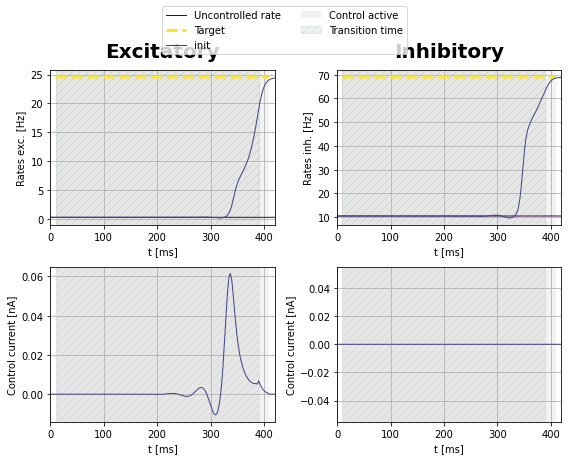

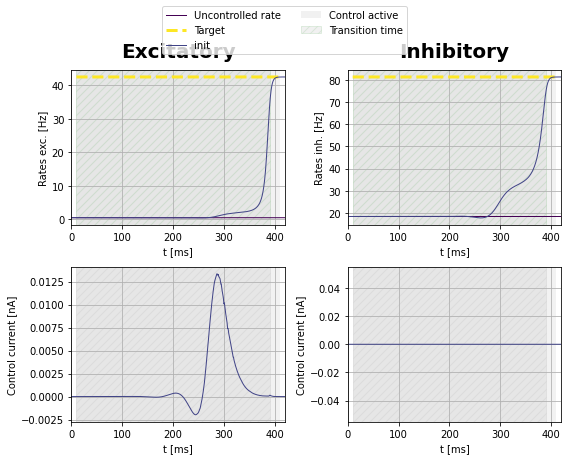

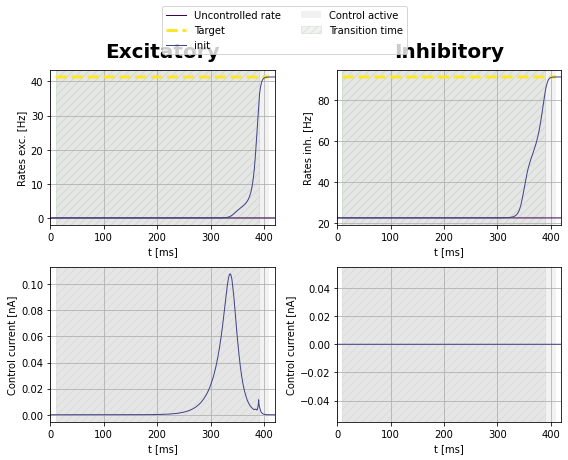

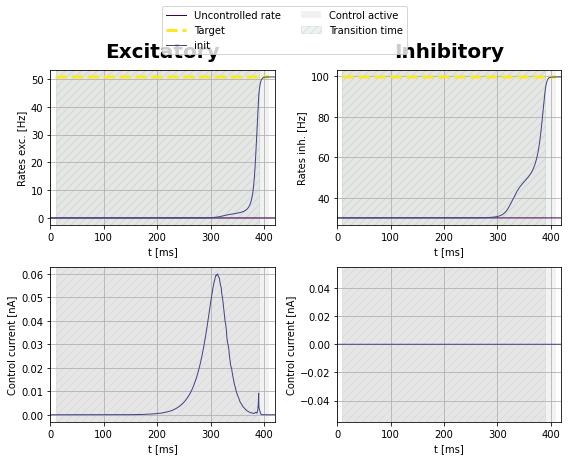

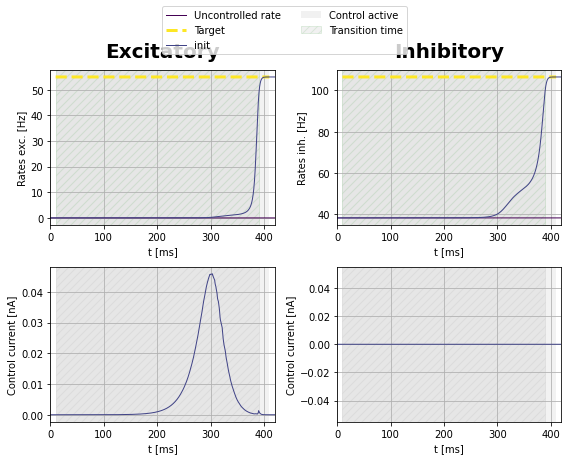

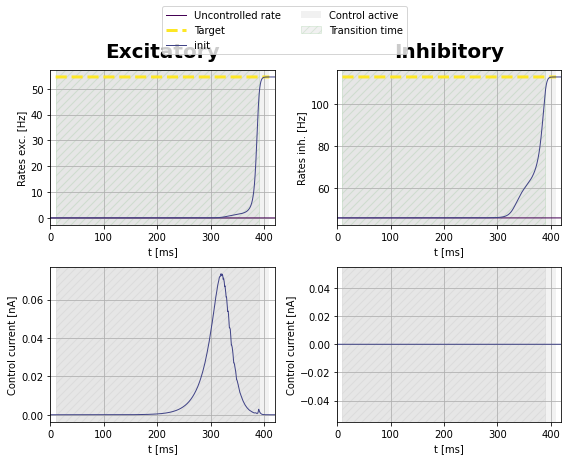

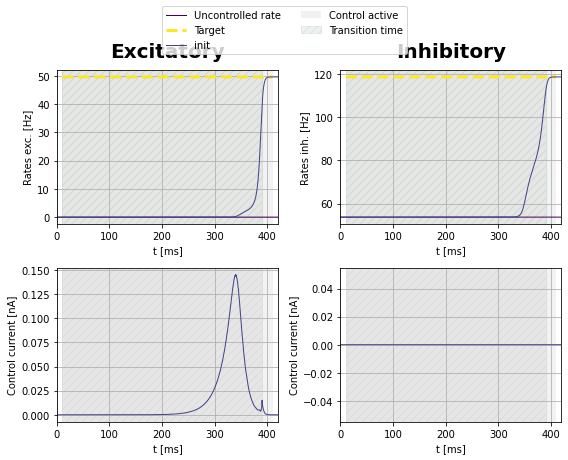

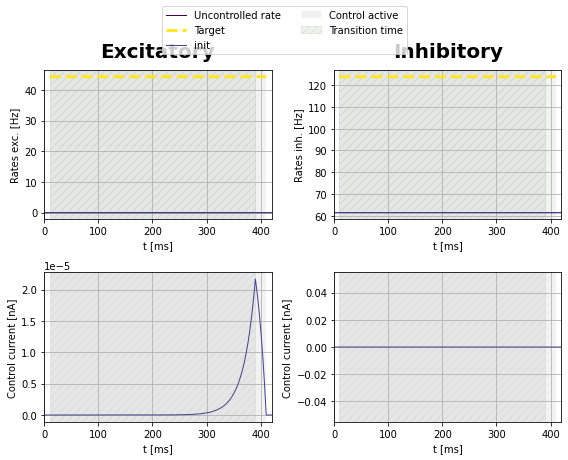

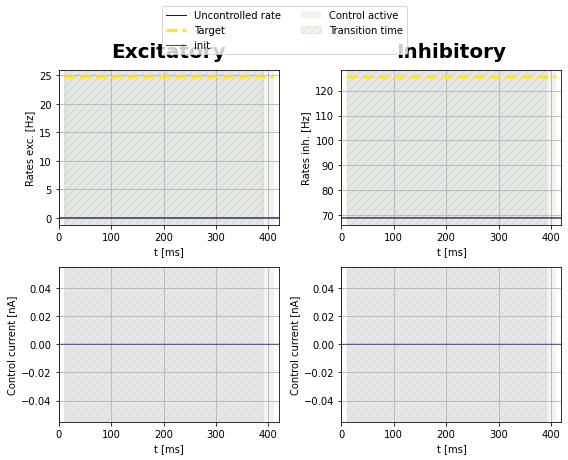

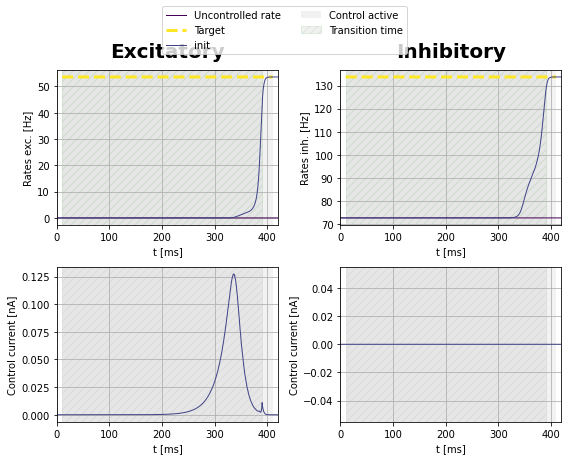

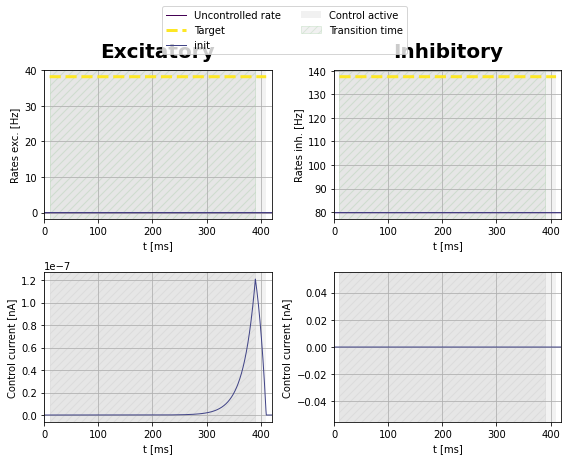

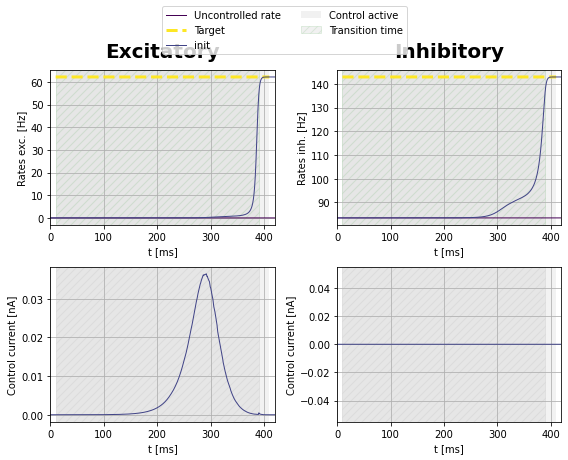

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
found solution for  13
-------  26 0.47500000000000014 0.4750000000000002
found so

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1035 , total integrated cost =  125.62569388627898
Improved over  1035  iterations in  99.60521083697677  seconds by  99.36160565830286  percent.
Problem in initial value trasfer:  Vmean_exc -56.694090936461656 -56.69409095416083
weight =  1561.1248104001095
set cost params:  1.0 1561.1248104001095 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19609.903194693256
Gradient descend method:  None
RUN  1 , total integrated cost =  19573.572387786924
RUN  2 , total integrated cost =  19573.500732034263
RUN  3 , total integrated cost =  19573.494083156093
RUN  4 , total integrated cost =  19573.39083044018
RUN  5 , total integrated cost =  19573.146511728322
RUN  6 , total integrated cost =  19573.130215121353
RUN  7 , total integrated cost =  19573.122162179916
RUN  8 , total integrated cost =  19571.855844139965
RUN  9 , total integrated cost =  19570.396373729745
RUN  10 , total integrated cost =  19570.385036305906
RUN  1

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  127 , total integrated cost =  19558.489458635777
Improved over  127  iterations in  9.626921689137816  seconds by  0.2621825082308078  percent.
Problem in initial value trasfer:  Vmean_exc -56.694085365188336 -56.69408545208574
-------  104 0.4250000000000001 0.7750000000000005
[0, 13, 26, 39, 52, 65, 78] []
closest index  78
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6187.436801147531
Gradient descend method:  None
RUN  1 , total integrated cost =  6120.786436626347
RUN  2 , total integrated cost =  6120.770164578543
RUN  3 , total integrated cost =  6120.770160605874
RUN  4 , total integrated cost =  6120.770160604903
RUN  5 , total integrated cost =  6120.770160604903
Control only changes marginally.
RUN  5 , total integrated cost =  6120.770160604903
Improved over  5  iterations in  0.7918378878384829  seconds by  1.0774516602781858  percent.
weight =  10.0
set c

...

Control only changes marginally.
RUN  46 , total integrated cost =  14529.112065425541
Improved over  46  iterations in  3.496620438992977  seconds by  0.12233755752674824  percent.
Problem in initial value trasfer:  Vmean_exc -56.67733101299795 -56.67732948118203
-------  143 0.6000000000000003 0.8750000000000006
------------------------------------------------------------
-------------------- 2
------------------------------------------------------------
found solution:  [0, 13, 26, 39, 52, 65, 78, 117, 143, 91]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
[0, 13, 26

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  249 , total integrated cost =  342.95179523878414
Improved over  249  iterations in  32.17162658832967  seconds by  94.58626433699749  percent.
Problem in initial value trasfer:  Vmean_exc -56.62553184082305 -56.62553167453743
weight =  178.47319202231455
set cost params:  1.0 178.47319202231455 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6120.452267196556
Gradient descend method:  None
RUN  1 , total integrated cost =  6119.799114695455
RUN  2 , total integrated cost =  6119.798847062468
RUN  3 , total integrated cost =  6119.1965485091905
RUN  4 , total integrated cost =  6119.007918430435
RUN  5 , total integrated cost =  6119.007676740933
RUN  6 , total integrated cost =  6119.007670928406
RUN  7 , total integrated cost =  6119.007670612614
RUN  8 , total integrated cost =  6119.007670591232
RUN  9 , total integrated cost =  6119.00767058995
RUN  10 , total integrated cost =  6119.007670589889
RUN  11 , total int

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  6119.007670589865
Control only changes marginally.
RUN  12 , total integrated cost =  6119.007670589865
Improved over  12  iterations in  1.7665075231343508  seconds by  0.02360277547516887  percent.
Problem in initial value trasfer:  Vmean_exc -56.625708662050606 -56.6257048163495
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006
------------------------------------------------------------
-------------------- 4
------------------------------------------------------------
found solution:  [0, 13, 26, 39, 52, 65, 78, 117, 143, 91, 130]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003


In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  7052.813223729279
set cost params:  1.0 7052.813223729279 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5894.920522495465
Gradient descend method:  None
RUN  1 , total integrated cost =  5894.678655818221
RUN  2 , total integrated cost =  5894.676919274599
RUN  3 , total integrated cost =  5894.676653964237
RUN  4 , total integrated cost =  5894.676598008892
RUN  5 , total integrated cost =  5894.676585275488
RUN  6 , total integrated cost =  5894.676581938037
RUN  7 , total integrated cost =  5894.6765805140985
RUN  8 , total integrated cost =  5894.676579911165
RUN  9 , total integrated cost =  5894.676579652198
RUN  10 , total integrated cost =  5894.676579539301
RUN  11 , total integrated c

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  5894.6765794404855
Improved over  24  iterations in  3.2498931400477886  seconds by  0.004138190736398428  percent.
Problem in initial value trasfer:  Vmean_exc -56.62680151548831 -56.62680519506334
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  260694.93146882483
set cost params:  1.0 260694.93146882483 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17547.641963775746
Gradient descend method:  None
RUN  1 , total integrated cost =  17547.554625542838
RUN  2 , total integrated cost =  17547.554392685226
RUN  3 , total integrated cost =  17547.55437549542
RUN  4 , total integrated cost =  17547.55437322696
RUN  5 , total integrated cost =  17547.55437288799
RUN  6 , total integrated cost =  17547.554372832463
RUN  7 , total integrated cost =  17547.554372823957
RUN  8 , total integrated cost =  17547.55437282254
RUN  9 , total integrated cost =  17547.5543728221

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  17547.55437282177
RUN  13 , total integrated cost =  17547.55437282177
Control only changes marginally.
RUN  13 , total integrated cost =  17547.55437282177
Improved over  13  iterations in  2.0185531470924616  seconds by  0.0004991608226134758  percent.
Problem in initial value trasfer:  Vmean_exc -56.69063115267975 -56.69063224578942
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  4571.377637041429
set cost params:  1.0 4571.377637041429 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17063.27723699869
Gradient descend method:  None
RUN  1 , total integrated cost =  17063.261809617397
RUN  2 , total integrated cost =  17063.260809188057
RUN  3 , total integrated cost =  17063.26060139293
RUN  4 , total integrated cost =  17063.26054217743
RUN  5 , total integrated cost =  17063.26052240971
RUN  6 , total integrated cost =  17063.26051572745
RUN  7 , total integrated cost =  17063.260513174802
R

...

RUN  1 , total integrated cost =  19599.21032450797
Control only changes marginally.
RUN  1 , total integrated cost =  19599.21032450797
Improved over  1  iterations in  0.2110914494842291  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.694085349102416 -56.694085436497396
-------  104 0.4250000000000001 0.7750000000000005
no convergence
weight =  177.52443006953973
set cost params:  1.0 177.52443006953973 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6086.484824092579
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  6086.484824092579
Control only changes marginally.
RUN  1 , total integrated cost =  6086.484824092579
Improved over  1  iterations in  0.20047039538621902  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62570866205006 -56.625704816348964
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  5349.99698709849
set cost params:  1.0 5349.99698709849 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28710.175438783157
Gradient descend method:  None
RUN  1 , total integrated cost =  28710.175438783157
Control only changes marginally.
RUN  1 , total integrated cost =  28710.175438783157
Improved over  1  iterations in  0.21253903582692146  seconds by  0.0  percent.
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
no convergence
weight =  51519.563368602496
set cost params:  1.0 51519.563368602496 0.0
interpolate

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  38612.26250722029
Control only changes marginally.
RUN  1 , total integrated cost =  38612.26250722029
Improved over  1  iterations in  0.21831099689006805  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027538382685 -56.70027535734367
[[True, False], [True, True], [True, False], [True, False], [True, True], [False, False], [True, False], [False, False], [False, False], [False, False], [True, True], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
no convergence
weight =  13571.897680362526
set cost params:  1.0 13571.897680362526 0.0
interpolate adjoint :  True True True

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  88.57724779774283
Gradient descend method:  None
RUN  1 , total integrated cost =  14.5811619612594
RUN  2 , total integrated cost =  13.460531327328193
RUN  3 , total integrated cost =  13.30663025513914
RUN  4 , total integrated cost =  13.276607303946633
RUN  5 , total integrated cost =  13.25246601518718
RUN  6 , total integrated cost =  13.19798613527453
RUN  7 , total integrated cost =  13.183563263454671
RUN  8 , total integrated cost =  13.174485398467723
RUN  9 , total integrated cost =  13.168422781135954
RUN  10 , total integrated cost =  13.16782121656828
RUN  11 , total integrated cost =  13.166977919836066
RUN  12 , total integrated cost =  13.166358685918418
RUN  13 , total integrated cost =  13.165312036698216
RUN  14 , total integrated cost =  13.16454870665804
RUN  15 , total integrated cost =  13.162775042318275
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  389 , total integrated cost =  48.414331164173575
Improved over  389  iterations in  98.23749482631683  seconds by  36.306418832827184  percent.
Problem in initial value trasfer:  Vmean_exc -56.62777583166032 -56.62777301613399
weight =  12190.444841452529
set cost params:  1.0 12190.444841452529 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5889.346557437815
Gradient descend method:  None
RUN  1 , total integrated cost =  5782.720436405123
RUN  2 , total integrated cost =  5726.4625973245065
RUN  3 , total integrated cost =  5328.183614225832
RUN  4 , total integrated cost =  5303.975206392672
RUN  5 , total integrated cost =  5276.714083637939
RUN  6 , total integrated cost =  5258.55969858267
RUN  7 , total integrated cost =  5224.213420147934
RUN  8 , total integrated cost =  5206.144903352699
RUN  9 , total integrated cost =  5174.797843384091
RUN  10 , total integrated cost =  5157.856478655316
RUN  11 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  392 , total integrated cost =  3608.0296502510478
Improved over  392  iterations in  64.71446220576763  seconds by  38.736333223685584  percent.
Problem in initial value trasfer:  Vmean_exc -56.6269912832578 -56.626994567498016
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  56.25586032375243
Gradient descend method:  None
RUN  1 , total integrated cost =  3.7303966922801353
RUN  2 , total integrated cost =  3.7286823441669252
RUN  3 , total integrated cost =  3.7271229270202526
RUN  4 , total integrated cost =  3.7258416669622108
RUN  5 , total integrated cost =  3.724382204055424
RUN  6 , total integrated cost =  3.723210315534785
RUN  7 , total integrated cost =  3.7219457421917945
RUN  8 , total integrated cost =  3.720933579744694
RUN  9 , total integrated cost =  3.7117358191751464
RUN  10 , total integrated cost =  3.7106143390680946
RU

...

RUN  10 , total integrated cost =  14517.721774450969
Control only changes marginally.
RUN  10 , total integrated cost =  14517.721774450969
Improved over  10  iterations in  2.1674919053912163  seconds by  0.04324001643951192  percent.
Problem in initial value trasfer:  Vmean_exc -56.67725014932728 -56.67725110999506
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  54.6216005297274
Gradient descend method:  None
RUN  1 , total integrated cost =  12.304080826085954
RUN  2 , total integrated cost =  12.303015783806664
RUN  3 , total integrated cost =  12.301696823595332
RUN  4 , total integrated cost =  12.300683744431543
RUN  5 , total integrated cost =  12.296701345439013
RUN  6 , total integrated cost =  12.29399805652866
RUN  7 , total integrated cost =  12.292646683706662
RUN  8 , total integrated cost =  12.291724498866227
RUN  9 , total integrated cost =  12.291608215201997
RU

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  231 , total integrated cost =  73.90618218140402
Improved over  231  iterations in  41.12628368474543  seconds by  1.702679677662772  percent.
Problem in initial value trasfer:  Vmean_exc -56.70026975451386 -56.700270233351745
weight =  52244.98380743398
set cost params:  1.0 52244.98380743398 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38608.6970163375
Gradient descend method:  None
RUN  1 , total integrated cost =  38547.49365274659
RUN  2 , total integrated cost =  38546.29654047841
RUN  3 , total integrated cost =  38544.625805401694
RUN  4 , total integrated cost =  38544.34533773175
RUN  5 , total integrated cost =  38544.10014892265
RUN  6 , total integrated cost =  38543.8447127049
RUN  7 , total integrated cost =  38543.58645503409
RUN  8 , total integrated cost =  38543.3593910644
RUN  9 , total integrated cost =  38543.13350297322
RUN  10 , total integrated cost =  38542.91713264345
RUN  11 , total integra

ERROR:root:Problem in initial value trasfer


RUN  110 , total integrated cost =  38538.14972426141
Control only changes marginally.
RUN  110 , total integrated cost =  38538.14972426141
Improved over  110  iterations in  17.40107353590429  seconds by  0.18272383563277117  percent.
Problem in initial value trasfer:  Vmean_exc -56.700270078637196 -56.700270541409125


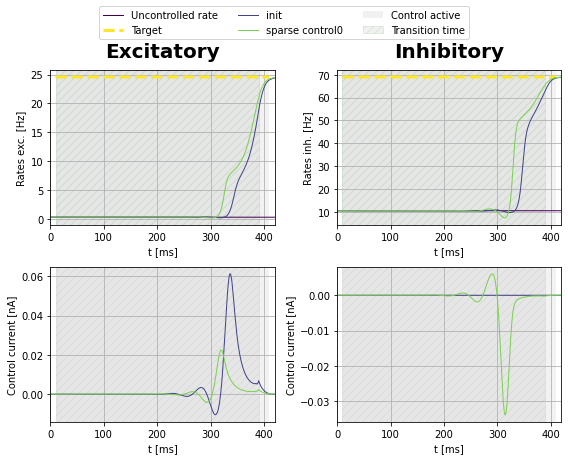

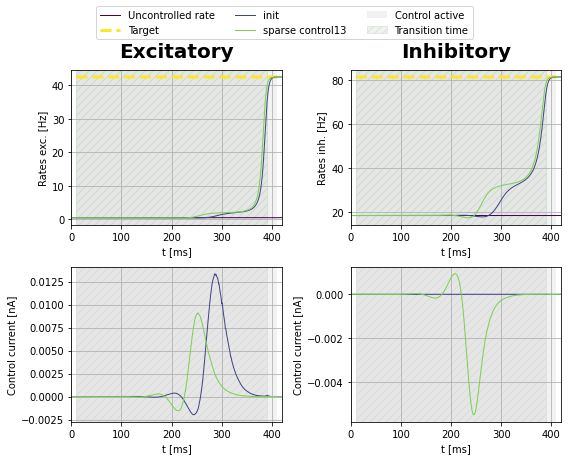

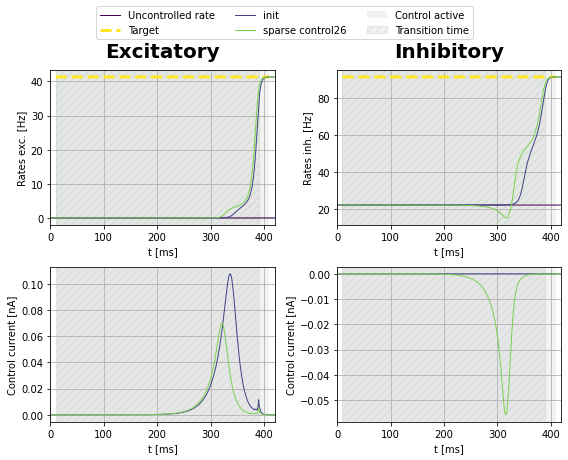

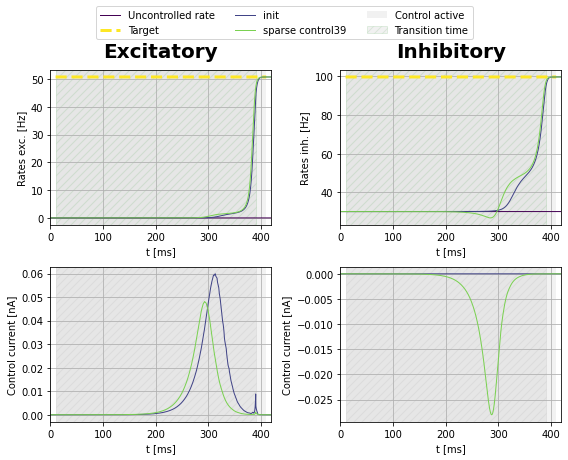

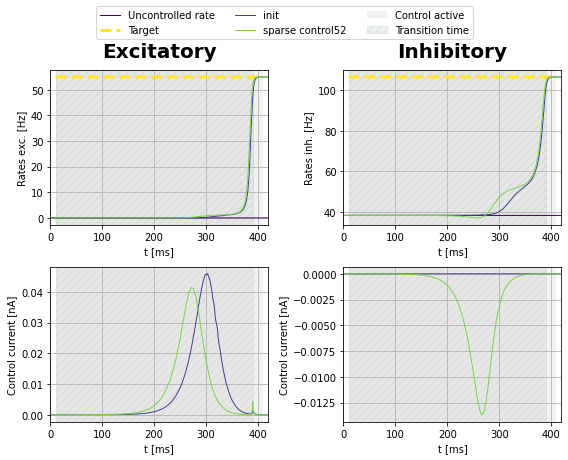

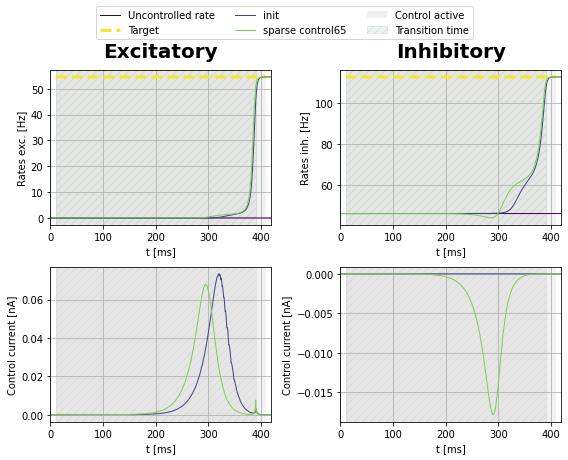

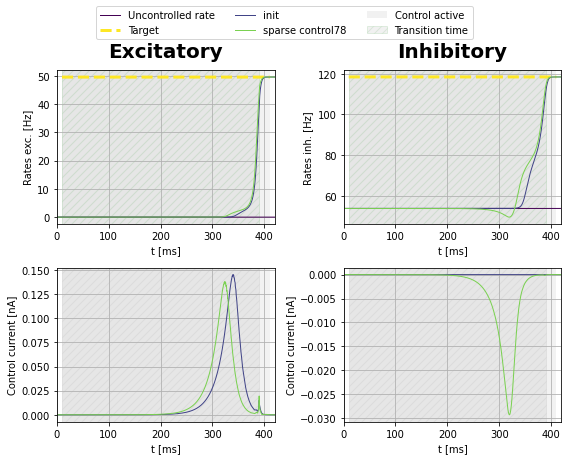

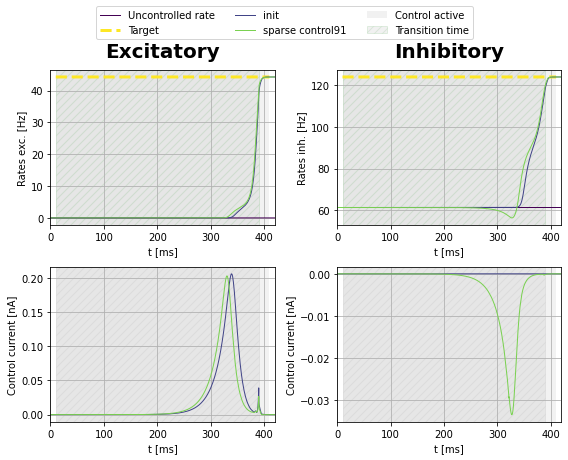

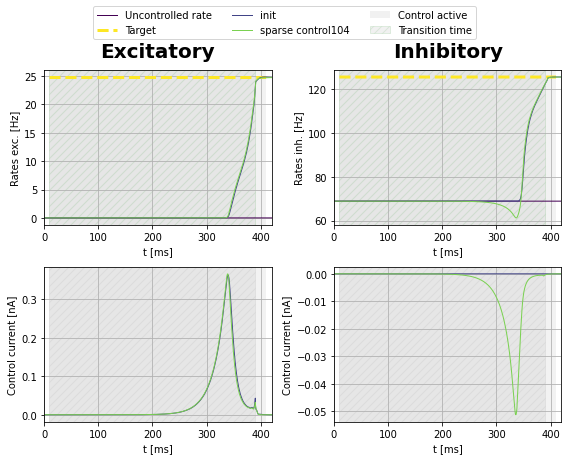

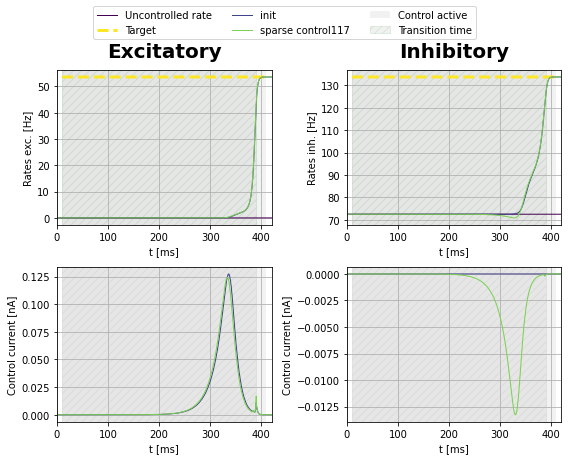

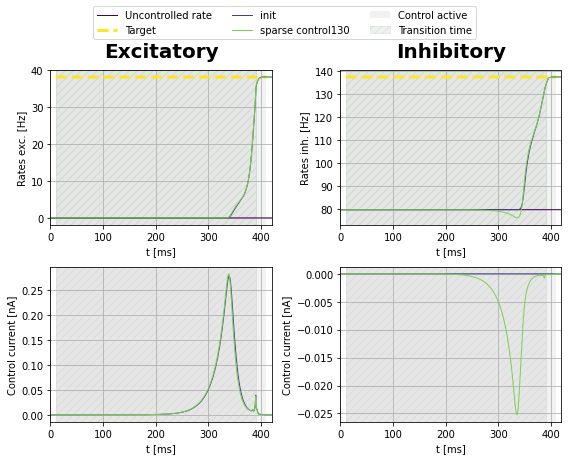

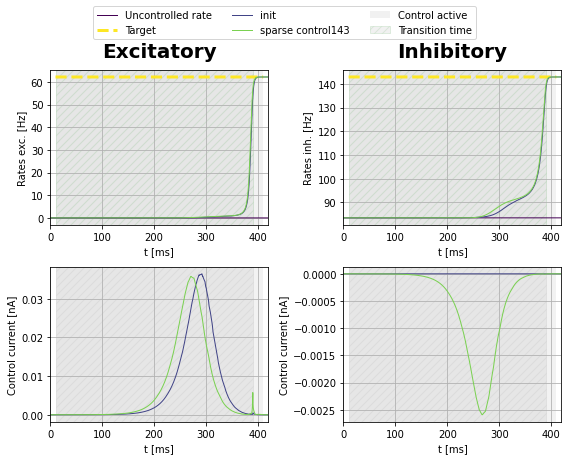

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [ ]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  19941.452693530668
set cost params:  1.0 19941.452693530668 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5884.190723433081
Gradient descend method:  None
RUN  1 , total integrated cost =  5879.931277204866
RUN  2 , total integrated cost =  5879.930448477353
RUN  3 , total integrated cost =  5879.930407575986
RUN  4 , total integrated cost =  5879.9304041740725
RUN  5 , total integrated cost =  5879.93040393225
RUN  6 , total integrated cost =  5879.930403909465
RUN  7 , total integrated cost =  5879.930403907431
RUN  8 , total integrated cost =  5879.930403907238
RUN  9 , total integrated cost =  5879.930403907228
RUN  10 , total integrated cost =  5879.930403907225
RUN  11 ,

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  5879.9304039072185
Control only changes marginally.
RUN  12 , total integrated cost =  5879.9304039072185
Improved over  12  iterations in  2.604041311889887  seconds by  0.07240281163723239  percent.
Problem in initial value trasfer:  Vmean_exc -56.62683225402081 -56.62683710721886
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  444117.5762158277
set cost params:  1.0 444117.5762158277 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17548.455743570146
Gradient descend method:  None
RUN  1 , total integrated cost =  17547.415960754894
RUN  2 , total integrated cost =  17546.320959584747
RUN  3 , total integrated cost =  17545.594974107764
RUN  4 , total integrated cost =  17544.610260115496
RUN  5 , total integrated cost =  17543.24448344658
RUN  6 , total integrated cost =  17542.38913169588
RUN  7 , total integrated cost =  17541.249581532575
RUN  8 , total integrated cost =  17540.50382109034

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1175 , total integrated cost =  16809.451482812532
Improved over  1175  iterations in  158.8764902111143  seconds by  4.211221041648571  percent.
Problem in initial value trasfer:  Vmean_exc -56.690654428791674 -56.69065478007975
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  7930.604993522978
set cost params:  1.0 7930.604993522978 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17060.938343882433
Gradient descend method:  None
RUN  1 , total integrated cost =  17059.762324173265
RUN  2 , total integrated cost =  17058.375876434362
RUN  3 , total integrated cost =  17056.74802979326
RUN  4 , total integrated cost =  17055.430941400416
RUN  5 , total integrated cost =  17053.691573157514
RUN  6 , total integrated cost =  17052.566315522152
RUN  7 , total integrated cost =  17051.36579532215
RUN  8 , total integrated cost =  17049.951180321674
RUN  9 , total integrated cost =  17048.0617283964

In [ ]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

In [ ]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [ ]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [ ]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

In [ ]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

In [ ]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

In [ ]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)